<a href="https://colab.research.google.com/github/zhilyaevaviktorija/machine_learning/blob/main/lectures/Lecture_2_(28_01_26)_%22classification_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ТУТОРИАЛ: SVM ДЛЯ КЛАССИФИКАЦИИ ДАННЫХ

## Часть 0: настройка окружения

In [1]:
# установка необходимых библиотек
!pip install numpy pandas matplotlib seaborn scikit-learn

# импорт
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

---

## Часть 1: загрузка и знакомство с данными

In [2]:
# загружаем датасет
wine = datasets.load_wine()
X = wine.data  # признаки (13 химических показателей)
y = wine.target  # классы (0, 1, 2 - регионы происхождения)
feature_names = wine.feature_names
target_names = wine.target_names

print(f"размер данных: {X.shape}")
print(f"количество классов: {len(np.unique(y))}")
print(f"названия классов: {target_names}")
print(f"признаки: {feature_names}")

размер данных: (178, 13)
количество классов: 3
названия классов: ['class_0' 'class_1' 'class_2']
признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


**Вопрос для анализа:**
```
Какой тип классификации предстоит решить?
A. бинарная классификация (2 класса)
B. многоклассовая классификация (3 класса)  
C. мультилейбл классификация (несколько меток одновременно)
D. ординальная классификация (упорядоченные классы)
```

В данном примере представлена **многоклассовая классификация**, поскольку переменная *y* содержит 3 класса: ['class_0' 'class_1' 'class_2'].

---

## Часть 2: изучение данных с графиками

In [3]:
# создаем DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['wine_type'] = df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

# первые 5 строк
print(df.head())

# базовая статистика
print(df.describe())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target wine_type  
0

/tmp/ipython-input-1934804563.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='wine_type', data=df, palette='Set2')


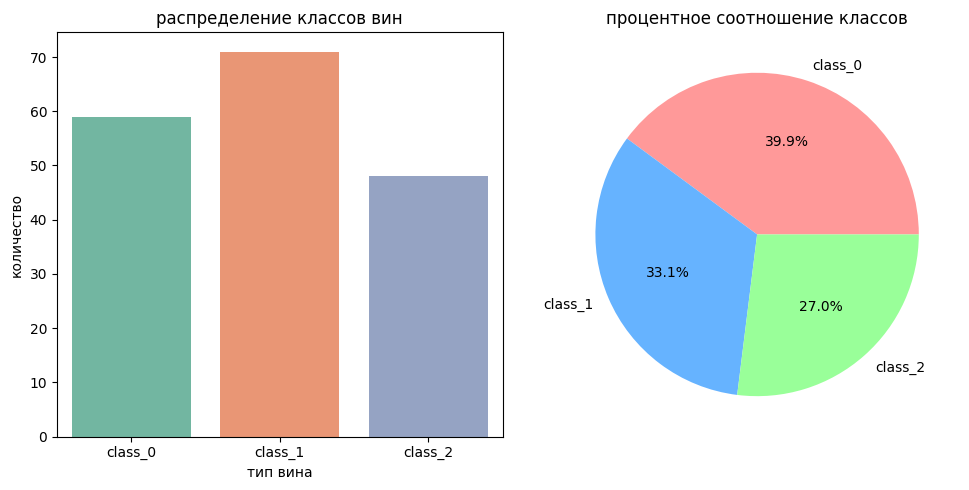

In [4]:
plt.figure(figsize=(10, 5))

# гистограмма по классам
plt.subplot(1, 2, 1)
sns.countplot(x='wine_type', data=df, palette='Set2')
plt.title('распределение классов вин')
plt.xlabel('тип вина')
plt.ylabel('количество')

# круговая диаграмма
plt.subplot(1, 2, 2)
class_counts = df['target'].value_counts()
plt.pie(class_counts, labels=target_names, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('процентное соотношение классов')

plt.tight_layout()
plt.show()

**Вопрос для анализа:**
```
На основе визуализации распределения классов, какой вывод можно сделать?
A. данные сильно несбалансированы (один класс доминирует)
B. данные умеренно сбалансированы (разница между классами не критична)
C. данные идеально сбалансированы (одинаковое количество примеров)
D. нельзя определить баланс без дополнительной информации
```

Исходя из анализа представленных графиков, можно сделать вывод о том, что **данные умеренно сбалансированы (разница между классами не критична)**. Это подтверждается умеренно равномерным распределением данных по колонкам в bar chart и секторам в pie chart.

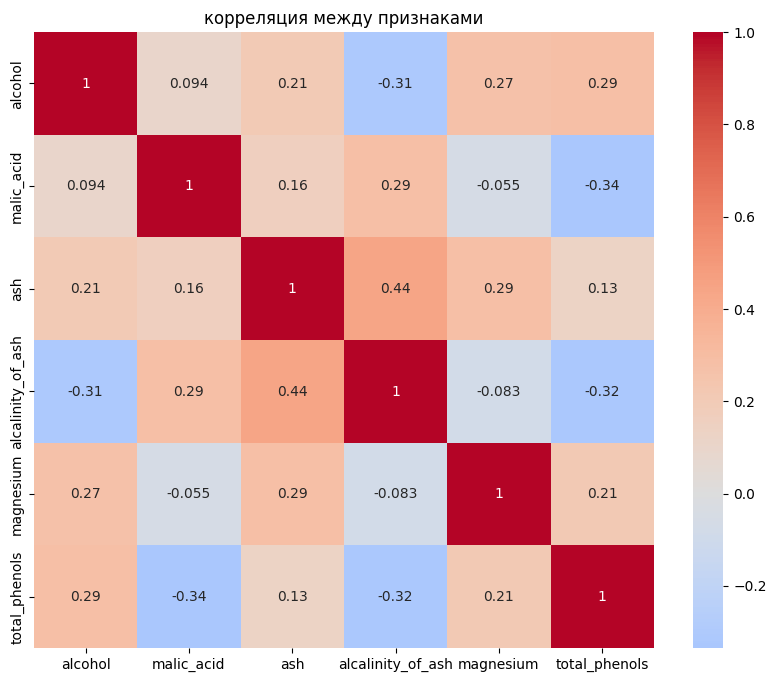

In [5]:
# корреляционная матрица (первые 6 признаков для наглядности)
plt.figure(figsize=(10, 8))
corr_matrix = df[feature_names[:6]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('корреляция между признаками')
plt.show()

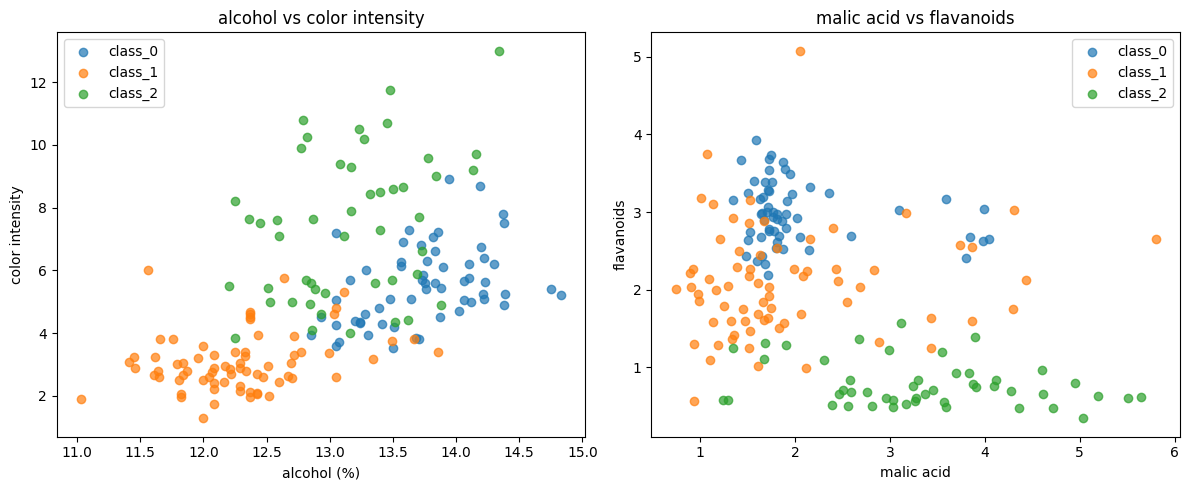

In [6]:
# берем два самых информативных признака (по описанию датасета)
plt.figure(figsize=(12, 5))

# alcohol vs color intensity
plt.subplot(1, 2, 1)
for i, wine_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['alcohol'],
                df[df['target'] == i]['color_intensity'],
                label=wine_class, alpha=0.7)
plt.xlabel('alcohol (%)')
plt.ylabel('color intensity')
plt.legend()
plt.title('alcohol vs color intensity')

# malic acid vs flavanoids
plt.subplot(1, 2, 2)
for i, wine_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['malic_acid'],
                df[df['target'] == i]['flavanoids'],
                label=wine_class, alpha=0.7)
plt.xlabel('malic acid')
plt.ylabel('flavanoids')
plt.legend()
plt.title('malic acid vs flavanoids')

plt.tight_layout()
plt.show()

**Вопрос для анализа:**
```
Основываясь на 2D визуализации данных, какой вывод наиболее верен?
A. классы линейно разделимы в 2D пространстве выбранных признаков
B. классы полностью перекрываются, разделение невозможно
C. классы частично разделимы, но потребуется многомерная граница
D. данные содержат явные выбросы, мешающие анализу
```

Согласно представленным scatter plots, **классы частично разделимы, но потребуется многомерная граница**. На диаграмме *'alcohol vs color intensity'* класс 1 четко отделим от классов 0 и 2, которые частично перекрываются. На диаграмме *'malic acid vs flavanoids'* класс 2 четко отделим от классов 0 и 1, которые частично перекрываются.

---

## Часть 3: математические основы SVM

### 3.1 что такое SVM? понимание через аналогии

**SVM (Support Vector Machine, метод опорных векторов)** — это алгоритм, который находит **оптимальную границу** между классами.

**Представьте:**
- у вас есть два типа шариков на столе: красные и синие
- вы хотите провести линию, которая их разделяет
- таких линий можно провести бесконечно много
- SVM выбирает **линию с максимальным запасом** от ближайших шариков каждой группы

### 3.2 ключевые компоненты SVM

#### **Support vectors (опорные векторы)**
- это самые "сложные" точки данных — те, которые находятся ближе всего к разделяющей границе
- именно они "поддерживают" (support) границу
- если убрать все остальные точки, граница останется прежней
- в реальности: пациенты с пограничными анализами, отзывы с неявной тональностью

#### **Margin (зазор)**
- расстояние от разделяющей линии до ближайших точек каждого класса
- чем больше зазор — тем устойчивее модель к шуму в данных
- SVM специально **максимизирует этот зазор** (maximum margin classifier)

#### **Hyperplane (гиперплоскость)**
- в 2D: линия (y = kx + b)
- в 3D: плоскость
- в n-мерном пространстве: (n-1)-мерная "плоскость", разделяющая пространство
- математически: w₁x₁ + w₂x₂ + ... + wₙxₙ + b = 0

### 3.3 как SVM работает в многомерных пространствах?

**Проблема:** в реальных данных признаки могут быть неразделимы прямой линией в исходном пространстве.

**Решение SVM: ядерный трюк (kernel trick)**

1. **Неявное преобразование:** данные переводятся в пространство более высокой размерности
2. **Магия вычислений:** SVM вычисляет скалярные произведения в новом пространстве, не вычисляя само преобразование
3. **Результат:** в новом пространстве данные становятся линейно разделимыми

**Пример:** представьте, что у вас есть круг красных точек внутри кольца синих. В 2D их нельзя разделить прямой, но если добавить третье измерение (расстояние от центра), они становятся разделимыми плоскостью.

### 3.4 основные типы ядер (kernels)

**Ядро** — функция, которая позволяет SVM работать с нелинейно разделимыми данными:

- **Линейное ядро:** для линейно разделимых данных (самый простой случай)
- **Полиномиальное ядро:** добавляет полиномиальные комбинации признаков
- **RBF (радиально-базисное ядро):** наиболее популярное, создает сложные нелинейные границы
- **Сигмоидное ядро:** похоже на нейронную сеть

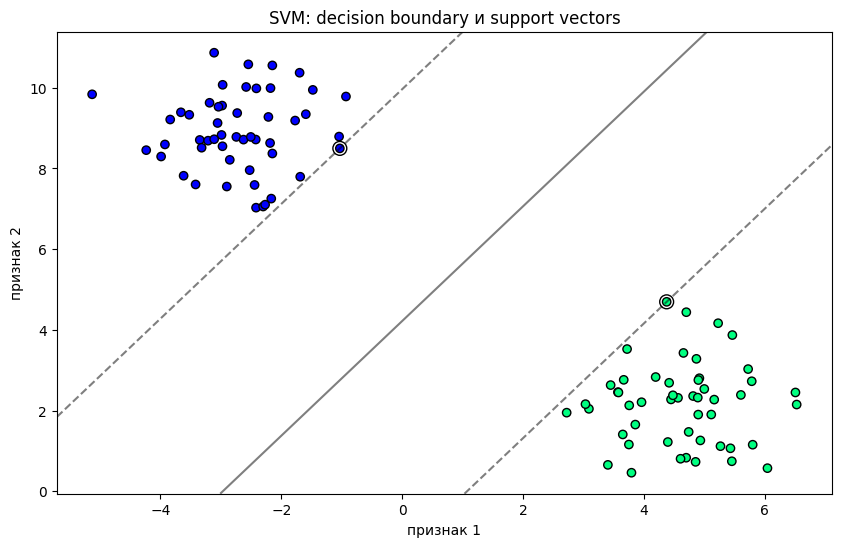

In [7]:
# визуализация для понимания
from sklearn.datasets import make_blobs

# создаем искусственные данные
X_visual, y_visual = make_blobs(n_samples=100, centers=2, random_state=42)

# обучаем SVM
svm_visual = SVC(kernel='linear')
svm_visual.fit(X_visual, y_visual)

# функция для визуализации SVM
def plot_svm_boundary(model, X, y):
    plt.figure(figsize=(10, 6))

    # точки данных
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')

    # decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # сетка для построения границы
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # граница и margin
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=100, linewidth=1, facecolors='none', edgecolors='k')

    plt.xlabel('признак 1')
    plt.ylabel('признак 2')
    plt.title('SVM: decision boundary и support vectors')
    plt.show()

plot_svm_boundary(svm_visual, X_visual, y_visual)

**Вопрос для анализа:**
```
В контексте SVM, какие утверждения верны о support vectors?
A. это все точки обучающей выборки
B. это точки, наиболее удаленные от разделяющей гиперплоскости
C. это точки, лежащие на границе зазора или внутри него
D. удаление support vectors не изменяет разделяющую гиперплоскость
E. количество support vectors обратно пропорционально степени регуляризации
```

**C. это точки, лежащие на границе зазора или внутри него**; **E. количество support vectors обратно пропорционально степени регуляризации** (при увеличении параметра регуляции зазор сужается, т.е. количество support vectors уменьшается, и наоборот, при уменьшении параметра регуляции зазор расширяется, т.е. захватывается большее количество support vectors).

---

## Часть 4: подготовка данных для SVM

In [8]:
# разделяем данные (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size: {X_train.shape}")
print(f"test size: {X_test.shape}")
print(f"train class distribution: {np.bincount(y_train)}")
print(f"test class distribution: {np.bincount(y_test)}")

train size: (142, 13)
test size: (36, 13)
train class distribution: [47 57 38]
test class distribution: [12 14 10]


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # только transform, не fit!

print("пример до масштабирования (первые 3 признака):")
print(X_train[0, :3])
print("\nпример после масштабирования (первые 3 признака):")
print(X_train_scaled[0, :3])

пример до масштабирования (первые 3 признака):
[13.28  1.64  2.84]

пример после масштабирования (первые 3 признака):
[ 0.38580089 -0.63787118  1.77666817]


**Вопрос для анализа:**
```
Почему масштабирование признаков критично для SVM?
A. SVM использует расстояния между точками, которые зависят от масштаба признаков
B. ядро RBF чувствительно к абсолютным значениям признаков
C. градиентные методы оптимизации сходятся медленнее без масштабирования
D. регуляризация параметра C действует по-разному на признаки разного масштаба
```

A. SVM использует расстояния между точками, которые зависят от масштаба признаков;
B. ядро RBF чувствительно к абсолютным значениям признаков;
D. регуляризация параметра C действует по-разному на признаки разного масштаба

---

## Часть 5: обучение SVM

In [10]:
# создаем и обучаем модель
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# предсказания
y_pred_linear = svm_linear.predict(X_test_scaled)

# оценка
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"линейный SVM accuracy: {accuracy_linear:.2%}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_linear, target_names=target_names))

линейный SVM accuracy: 94.44%

classification report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



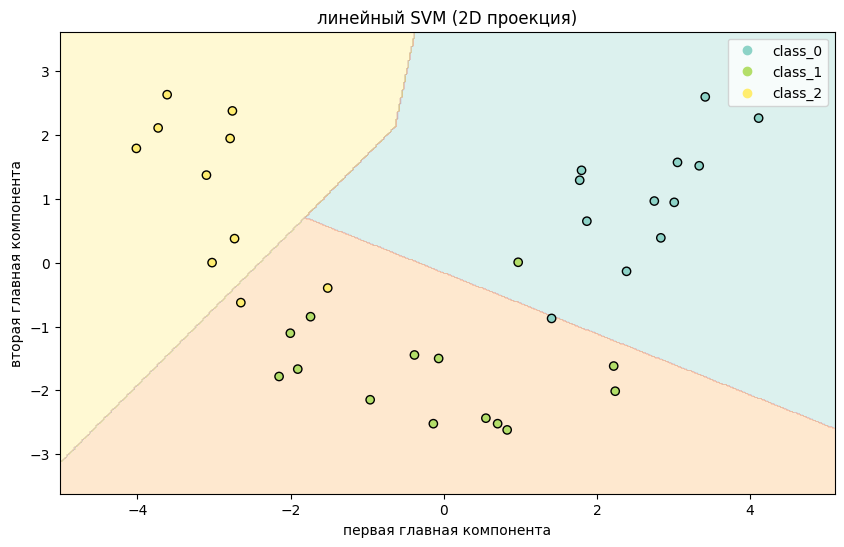

In [11]:
# используем PCA для уменьшения до 2D для визуализации
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

# создаем сетку для границы
def plot_decision_boundary_2d(model, X, y, title):
    h = .02  # шаг сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # предсказание для каждой точки сетки
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set3')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='Set3')
    plt.xlabel('первая главная компонента')
    plt.ylabel('вторая главная компонента')
    plt.title(title)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
    plt.show()

plot_decision_boundary_2d(svm_linear, X_test_pca, y_test, "линейный SVM (2D проекция)")

---

## Часть 6: меняем и переобучаем

In [12]:
# SVM с RBF ядром (по умолчанию)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF SVM accuracy: {accuracy_rbf:.2%}")

RBF SVM accuracy: 97.22%


### 6.2 подбор параметров C и gamma

**Что такое гиперпараметры?**
- параметры, которые задаются до обучения модели
- не обучаются на данных, а выбираются экспериментально
- контролируют поведение и сложность модели

**Гиперпараметры SVM:**

**C (параметр регуляризации):**
- контролирует компромисс между точностью на обучающих данных и обобщающей способностью
- **маленькое C:** большая регуляризация → допускаем ошибки на обучающих данных ради большего зазора и лучшего обобщения
- **большое C:** маленькая регуляризация → стремимся правильно классифицировать все обучающие точки, рискуя переобучиться
- аналогия: C — это "строгость учителя". Маленькое C: учитель разрешает некоторые ошибки. Большое C: учитель требует идеального выполнения

**gamma (параметр ядра RBF):**
- определяет "радиус влияния" одной точки
- **маленькое gamma:** каждая точка имеет большое влияние → плавная граница решений
- **большое gamma:** точки имеют малое влияние → граница следует за отдельными точками, может стать извилистой
- аналогия: gamma — это "фокус зрения". Маленькое gamma: видим общую картину. Большое gamma: фокусируемся на деталях

C=0.01: accuracy = 38.89%
C=0.1: accuracy = 97.22%
C=1: accuracy = 97.22%
C=10: accuracy = 94.44%
C=100: accuracy = 94.44%


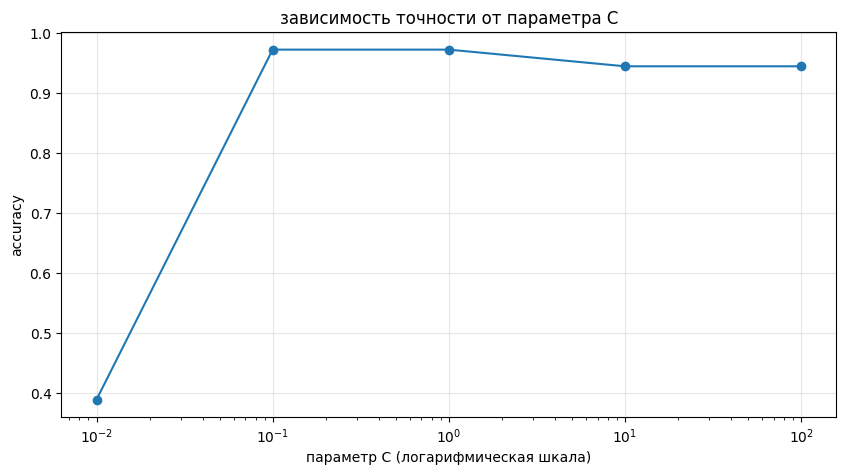

In [13]:
# пробуем разные значения C
C_values = [0.01, 0.1, 1, 10, 100]
accuracies = []

for C in C_values:
    svm_temp = SVC(kernel='rbf', C=C, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc = svm_temp.score(X_test_scaled, y_test)
    accuracies.append(acc)
    print(f"C={C}: accuracy = {acc:.2%}")

# график зависимости accuracy от C
plt.figure(figsize=(10, 5))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('параметр C (логарифмическая шкала)')
plt.ylabel('accuracy')
plt.title('зависимость точности от параметра C')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# используем найденные лучшие параметры
best_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 94.44%


**Вопрос для анализа:**
```
Как параметр C влияет на поведение SVM?
A. большие значения C приводят к большей регуляризации и большему зазору
B. малые значения C допускают больше ошибок на обучающей выборке ради большего зазора
C. C не влияет на положение разделяющей гиперплоскости, только на скорость обучения
D. оптимальное значение C всегда равно 1 для стандартизованных данных
```

B. малые значения C допускают больше ошибок на обучающей выборке ради большего зазора

---

## Часть 7: матрица ошибок и метрики

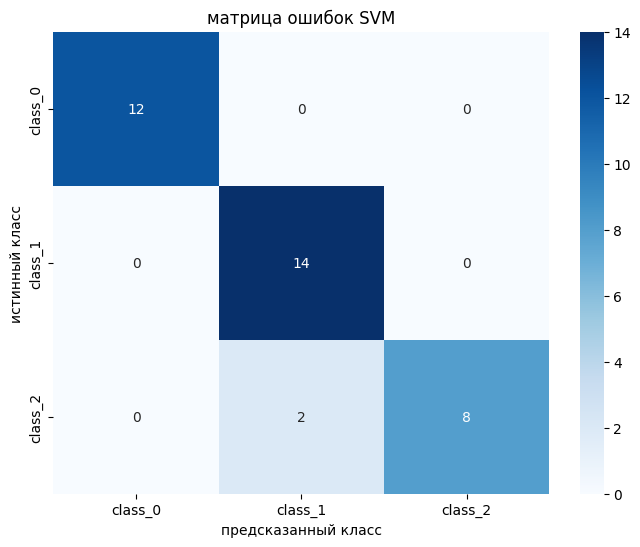

In [15]:
# вычисляем матрицу ошибок
cm = confusion_matrix(y_test, y_pred_best)

# визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.title('матрица ошибок SVM')
plt.show()

In [16]:
print("детальный отчет по классификации:")
print(classification_report(y_test, y_pred_best, target_names=target_names))

# вычисляем дополнительные метрики вручную
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"\nитоговые метрики:")
print(f"precision: {precision:.2%}  # точность (сколько из предсказанных правильные)")
print(f"recall:    {recall:.2%}    # полнота (сколько из реальных нашли)")
print(f"F1-score:  {f1:.2%}     # баланс precision и recall")

детальный отчет по классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36


итоговые метрики:
precision: 95.14%  # точность (сколько из предсказанных правильные)
recall:    94.44%    # полнота (сколько из реальных нашли)
F1-score:  94.32%     # баланс precision и recall


**Вопрос для анализа:**
```
При оценке многоклассового классификатора, какие метрики наиболее информативны?
A. только accuracy, так как она дает общую картину
B. precision и recall для каждого класса в отдельности
C. macro-averaged метрики, которые дают равный вес каждому классу
D. weighted метрики, которые учитывают распределение классов
E. confusion matrix для визуального анализа ошибок
```

B. precision и recall для каждого класса в отдельности;
C. macro-averaged метрики, которые дают равный вес каждому классу;
D. weighted метрики, которые учитывают распределение классов;
E. confusion matrix для визуального анализа ошибок.

---

## Часть 8: анализ ошибок

In [17]:
# находим индексы ошибок
error_indices = np.where(y_pred_best != y_test)[0]

print(f"количество ошибок: {len(error_indices)}")

if len(error_indices) > 0:
    print("\nпримеры ошибок:")

    for i, idx in enumerate(error_indices[:3]):  # покажем первые 3
        print(f"\nошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  вероятности классов: {best_svm.decision_function(X_test_scaled[idx:idx+1])}")

количество ошибок: 2

примеры ошибок:

ошибка 1:
  истинный класс: class_2
  предсказанный:  class_1
  вероятности классов: [[-0.21545195  2.17921522  1.13311604]]

ошибка 2:
  истинный класс: class_2
  предсказанный:  class_1
  вероятности классов: [[-0.19428459  2.16299388  1.10191035]]


In [18]:
print(f"количество support vectors: {len(best_svm.support_vectors_)}")
print(f"количество support vectors по классам: {best_svm.n_support_}")
print(f"процент точек, являющихся support vectors: {len(best_svm.support_vectors_)/len(X_train):.1%}")

количество support vectors: 57
количество support vectors по классам: [16 24 17]
процент точек, являющихся support vectors: 40.1%


---

## Часть 9: график обучения (learning curve)

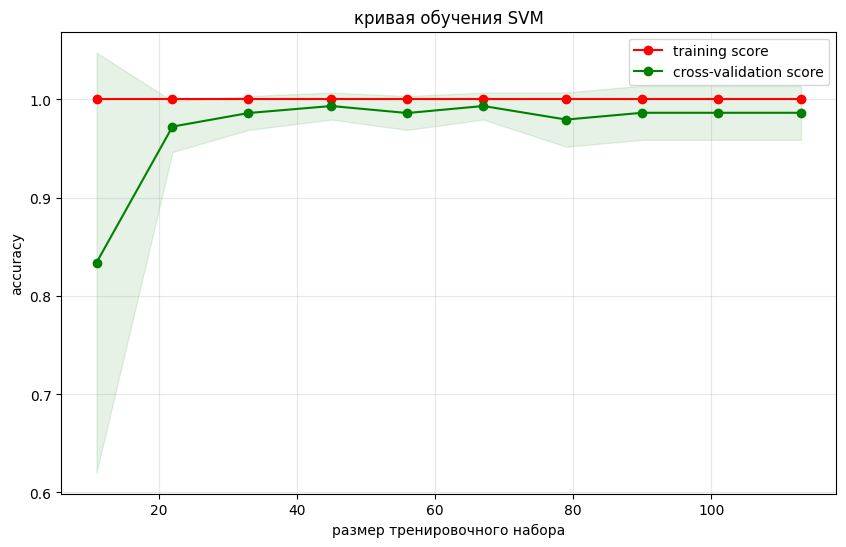

In [19]:
from sklearn.model_selection import learning_curve

# вычисляем learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_svm, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# средние значения
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# график
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('размер тренировочного набора')
plt.ylabel('accuracy')
plt.title('кривая обучения SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

**Вопрос для анализа:**
```
На основе кривой обучения, какой вывод можно сделать о модели?
A. модель недообучается (обе кривые сходятся к низкому значению)
B. модель переобучается (большой разрыв между кривыми)
C. модель хорошо обобщает (кривые сходятся к высокому значению)
D. для улучшения нужны больше данных (кривые еще не сошлись)
```

**C. модель хорошо обобщает (кривые сходятся к высокому значению)**, поскольку кривые стабилизируются, расстояние между ними небольшое.

---

## ДОМАШНЕЕ ЗАДАНИЕ

### **Задача:** повторите туториал на датасете **Iris**

**Датасет Iris:**
- 150 примеров цветков ириса
- 3 вида (Setosa, Versicolor, Virginica)
- 4 признака (длина/ширина чашелистика и лепестка)

### **Требования:**
1. **часть 1-2: анализ данных**
   - загрузите датасет `sklearn.datasets.load_iris()`
   - создайте 2 графика распределения классов
   - визуализируйте данные в 2D (выберите 2 любых признака)

2. **часть 3-5: подготовка и обучение**
   - разделите данные 70/30 с `stratify`
   - масштабируйте признаки
   - обучите SVM с линейным ядром

3. **часть 6: эксперименты**
   - попробуйте 3 разных значения C: 0.1, 1, 10
   - сравните accuracy каждой модели
   - выберите лучшую

4. **часть 7-8: оценка**
   - постройте матрицу ошибок для лучшей модели
   - вычислите precision, recall, F1-score
   - найдите и проанализируйте 2 примера ошибок

5. **часть 9: анализ**
   - постройте кривую обучения
   - ответьте: модель переобучается или недообучается?
   - что можно улучшить?

### **Формат сдачи:**
- **Colab ноутбук** с выполненным кодом
- **краткий отчет** (3-5 предложений) с выводами:
  - какая точность достигнута?
  - на каких классах чаще ошибается модель?
  - какие параметры SVM сработали лучше всего?

### **Критерии оценки:**
1. корректная загрузка и анализ данных
2. правильное разделение и масштабирование
3. обучение SVM с разными параметрами (показать, что вы делали как минимум 2 прогона с разными гиперпараметрами, 1 прогон даёт 1 балл)
4. визуализация матрицы ошибок
5. вычисление метрик precision, recall, F1
6. построение кривой обучения
7. представлены ответы на все вопросы из списка требований

### **Дедлайн:** 14 февраля, 23:59 в свои учебные репозитории